# Notebook de referência — BER vs Eb/N0 (baseband)
Este notebook fornece um esqueleto em Python para simular BER por Monte Carlo para M-PSK e M-QAM, calcular curvas teóricas aproximadas e gerar figuras. Use-o como inspiração para integrar pulso, banda passante e filtro casado no seu `marimo` notebook.

In [3]:
# Imports e estado determinístico
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
import os

rng = np.random.default_rng(12345)
OUT_DIR = 'output/trabalho2'
os.makedirs(OUT_DIR, exist_ok=True)
plt.rcParams['figure.dpi'] = 120

## Funções utilitárias: Gray code, constelações e mapeamento/desmapeamento

In [4]:
def int_to_gray(n):
    return n ^ (n >> 1)

def gray_to_int(g):
    # inverse Gray code (binary)
    n = 0
    while g:
        n ^= g
        g >>= 1
    return n

def qam_constellation(M):
    # construçao de QAM quadrada (M must be square)
    m = int(np.sqrt(M))
    assert m*m == M, 'M must be a perfect square for square QAM'
    levels = np.arange(-(m-1), m, 2)
    xv, yv = np.meshgrid(levels, levels[::-1])
    c = xv.flatten() + 1j*yv.flatten()
    # normaliza energia média para 1
    c = c / np.sqrt(np.mean(np.abs(c)**2))
    return c

def psk_constellation(M):
    k = np.arange(M)
    c = np.exp(1j*2*np.pi*k/M)
    c = c / np.sqrt(np.mean(np.abs(c)**2))
    return c

def bits_to_symbols(bits, M, kind='qam', gray=True):
    b = int(np.log2(M))
    assert bits.size % b == 0
    symbols = bits.reshape(-1, b)
    ints = symbols.dot(1 << np.arange(b)[::-1])
    if gray:
        ints = np.array([int_to_gray(int(x)) for x in ints], dtype=int)
    if kind == 'qam':
        const = qam_constellation(M)
    else:
        const = psk_constellation(M)
    return const[ints], ints, const

def symbols_to_bits(rx_symbols, const, b, gray=True):
    # decision by mínima distância euclidiana
    rx = np.asarray(rx_symbols).reshape(-1)
    d = np.abs(rx.reshape(-1,1) - const.reshape(1,-1))**2
    idx = np.argmin(d, axis=1)
    if gray:
        ints = np.array([gray_to_int(i) for i in idx], dtype=int)
    else:
        ints = idx
    bits = ((ints[:,None] & (1 << np.arange(b)[::-1])) > 0).astype(int)
    return bits.reshape(-1)

In [5]:
def add_awgn_noise(s, EbN0_dB, b):
    # s: complex symbols with unit average energy (Es=1)
    EbN0 = 10**(EbN0_dB/10)
    EsN0 = EbN0 * b
    sigma2 = 1/(2*EsN0)  # variance per complex dimension
    noise = np.sqrt(sigma2)*(rng.standard_normal(s.shape) + 1j*rng.standard_normal(s.shape))
    return s + noise

def ber_qam_theoretical(M, EbN0_dB):
    k = np.log2(M)
    x = np.sqrt(3*k/(M-1) * 10**(EbN0_dB/10))
    Q = 0.5*erfc(x/np.sqrt(2))
    Pb = 4*(1 - 1/np.sqrt(M))/k * Q
    return Pb

def ber_bpsk_theoretical(EbN0_dB):
    return 0.5*erfc(np.sqrt(10**(EbN0_dB/10)))

def ber_mpsk_approx(M, EbN0_dB):
    k = np.log2(M)
    EsN0 = 10**(EbN0_dB/10) * k
    arg = np.sqrt(2*EsN0) * np.sin(np.pi/M)
    return 0.5*erfc(arg/np.sqrt(2)) / k

## Simulação Monte Carlo (baseband)
A função abaixo realiza a simulação por Eb/N0 para uma modulação dada. Ajuste `num_symbols` para aumentar a precisão (custo computacional).

In [ ]:
def simulate_ber(M, kind='qam', EbN0_dB_list=None, num_symbols=200000, gray=True):
    if EbN0_dB_list is None:
        EbN0_dB_list = np.array([0,4,8,12,16,20,24])
    b = int(np.log2(M))
    bits_tx = rng.integers(0,2,size=num_symbols*b)
    s, ints_tx, const = bits_to_symbols(bits_tx, M, kind=kind, gray=gray)
    ber = []
    for Eb in EbN0_dB_list:
        rx = add_awgn_noise(s, Eb, b)
        bits_rx = symbols_to_bits(rx, const, b, gray=gray)
        ber_val = np.mean(bits_tx != bits_rx)
        ber.append(ber_val)
    return np.array(ber), EbN0_dB_list

## Execução de exemplo: QPSK (4-PSK) e 16-QAM
Iremos rodar uma simulação rápida para comparar com curvas teóricas aproximadas.

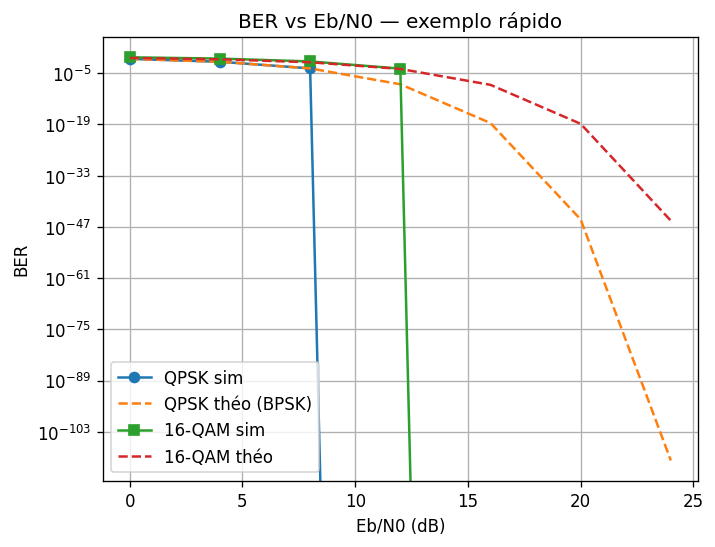

In [ ]:
EbN0_dB = np.array([0,4,8,12,16,20,24])
# QPSK
ber_qpsk, eb = simulate_ber(4, kind='psk', EbN0_dB_list=EbN0_dB, num_symbols=100000)
# 16-QAM
ber_16qam, _ = simulate_ber(16, kind='qam', EbN0_dB_list=EbN0_dB, num_symbols=100000)

# Curvas teóricas aproximadas
theo_16qam = ber_qam_theoretical(16, EbN0_dB)
theo_qpsk = ber_bpsk_theoretical(EbN0_dB)  # QPSK ~ BPSK per bit

plt.figure()
plt.semilogy(eb, ber_qpsk, 'o-', label='QPSK sim')
plt.semilogy(eb, theo_qpsk, '--', label='QPSK théo (BPSK)')
plt.semilogy(eb, ber_16qam, 's-', label='16-QAM sim')
plt.semilogy(eb, theo_16qam, '--', label='16-QAM théo')
plt.xlabel('Eb/N0 (dB)')
plt.ylabel('BER')
plt.grid(True, which='both')
plt.legend()
plt.tight_layout()
plt.show()

## Próximos passos (integração banda passante)
- Adicionar upsampling, pulso (RRC) e mistura para banda passante (fc).
- No receptor: demodulação coerente, filtro casado e amostragem em Ts.
- Comparar constelações pós-amostragem e salvar figuras em `output/trabalho2/`.